In [30]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import requests
import seaborn as sns
import os
from dotenv import load_dotenv
from io import StringIO
load_dotenv()

True

In [31]:
API_KEY = os.getenv('DUNE_API_KEY')
QUERY_ID = 6918017
url = f"https://api.dune.com/api/v1/query/{QUERY_ID}/results/csv?"
headers = {"X-Dune-API-Key": API_KEY}
response = requests.get(url, headers=headers)
df = pd.read_csv(StringIO(response.text))
df.to_csv('raw_query_results.csv', index=False)

**Analysis Report and Preparation**

In [32]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Dune Liquidity Analysis Report", explorative=True)
profile.to_file("dune_liquidity_analysis_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 277.53it/s]


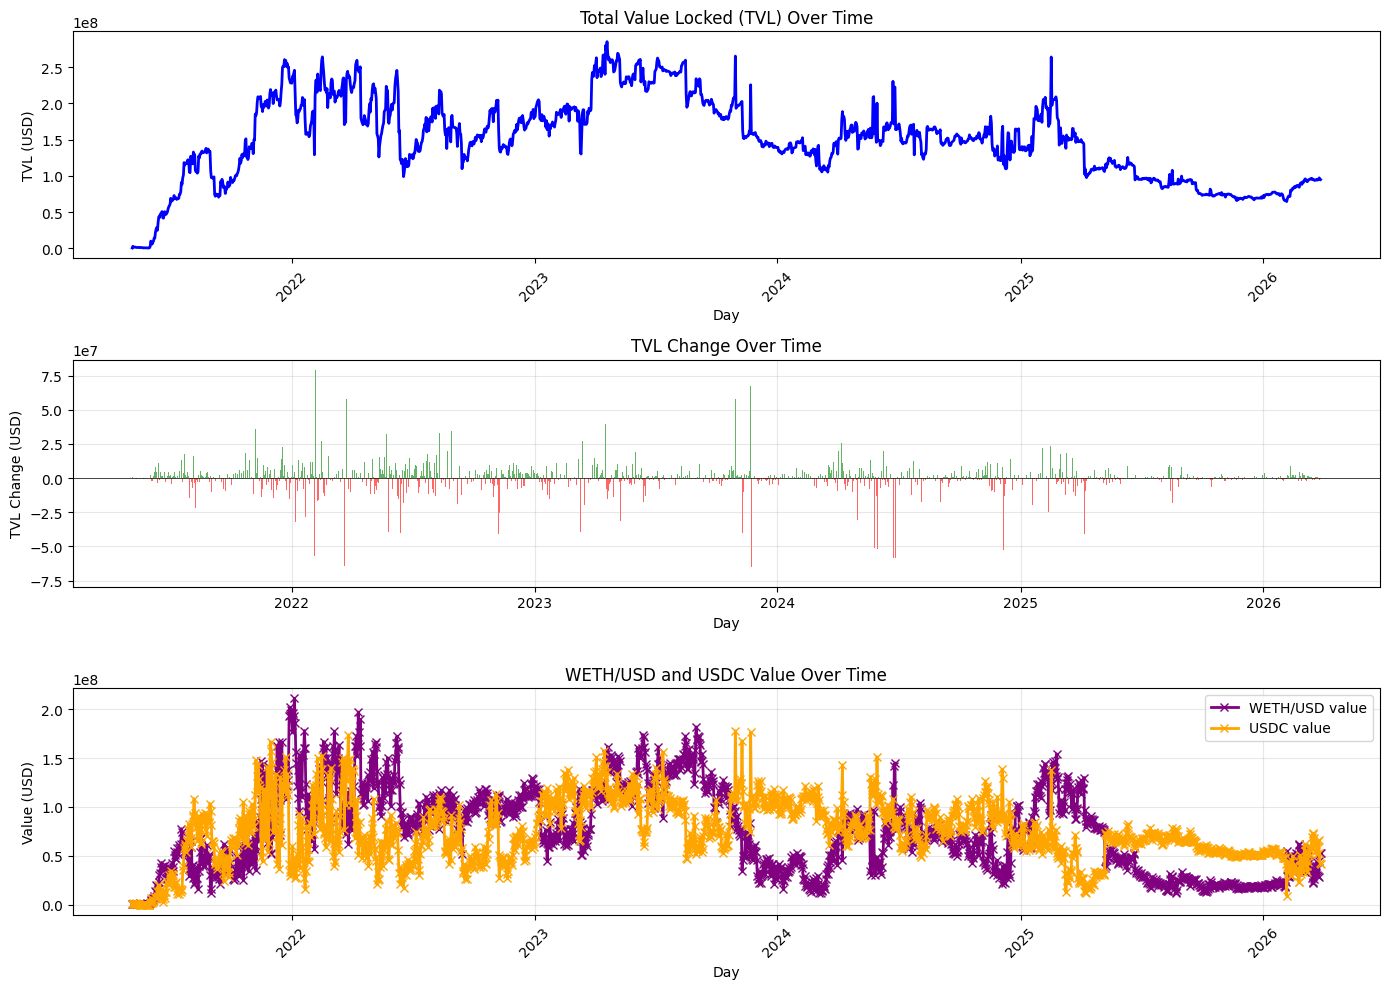

In [33]:
df['day'] = pd.to_datetime(df['day'])
df = df.sort_values('day').reset_index(drop=True)

df['tvl_change'] = df['tvl'].diff()
df['liquidity_flow'] = (df['tvl_change'] > 0).astype(int)
df = df.iloc[1:].reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df['day'], df['tvl'], color= 'blue', linewidth=2)
axes[0].set_title('Total Value Locked (TVL) Over Time')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('TVL (USD)')
axes[0].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

colors = ['green' if flow == 1 else 'red' for flow in df['liquidity_flow']]
axes[1].bar(df['day'], df['tvl_change'], color=colors, alpha= 0.6)
axes[1].set_title('TVL Change Over Time')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('TVL Change (USD)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['day'], df['weth_usd'], label='WETH/USD value', marker='x', color='purple', linewidth=2)
axes[2].plot(df['day'], df['usdc_usd'], label='USDC value', marker='x', color='orange', linewidth=2)
axes[2].set_title('WETH/USD and USDC Value Over Time')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Value (USD)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pool_liquidity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
df['prev_tvl_change'] = df['tvl_change'].shift(1)
df['prev_flow'] = df['liquidity_flow'].shift(1)

df['tvl_ma_3d'] = df['tvl'].rolling(window=3).mean()
df['tvl_ma_7d'] = df['tvl'].rolling(window=7).mean()
df['tvl_ma_30d'] = df['tvl'].rolling(window=30).mean()
df['tvl_momentum'] = df['tvl'] - df['tvl_ma_7d']


df['pool_ratio'] = df['weth_usd'] / (df['weth_usd'] + df['usdc_usd'])
df['tvl_volatility_7d'] = df['tvl'].rolling(window=7).std()
df['day_of_week'] = df['day'].dt.dayofweek
df['month'] = df['day'].dt.month
df['pct_from_ma7'] = (df['tvl'] - df['tvl_ma_7d']) / df['tvl_ma_7d'] * 100

df_clean = df.dropna().reset_index(drop=True)
df_clean.to_csv('features_ready.csv', index=False)

print(df_clean.columns.tolist())
print(f"\nTarget distribution:")
print(df_clean['liquidity_flow'].value_counts())
print(f"Percentage flowing IN: {df_clean['liquidity_flow'].mean() * 100:.1f}%")

['day', 'weth_balance', 'usdc_balance', 'weth_usd', 'usdc_usd', 'tvl', 'tvl_change', 'liquidity_flow', 'prev_tvl_change', 'prev_flow', 'tvl_ma_3d', 'tvl_ma_7d', 'tvl_ma_30d', 'tvl_momentum', 'pool_ratio', 'tvl_volatility_7d', 'day_of_week', 'month', 'pct_from_ma7']

Target distribution:
liquidity_flow
1    951
0    808
Name: count, dtype: int64
Percentage flowing IN: 54.1%


**Model Building**

Testing Accuracy: 72.44%
              precision    recall  f1-score   support

           0       0.75      0.63      0.68       166
           1       0.71      0.81      0.76       186

    accuracy                           0.72       352
   macro avg       0.73      0.72      0.72       352
weighted avg       0.73      0.72      0.72       352



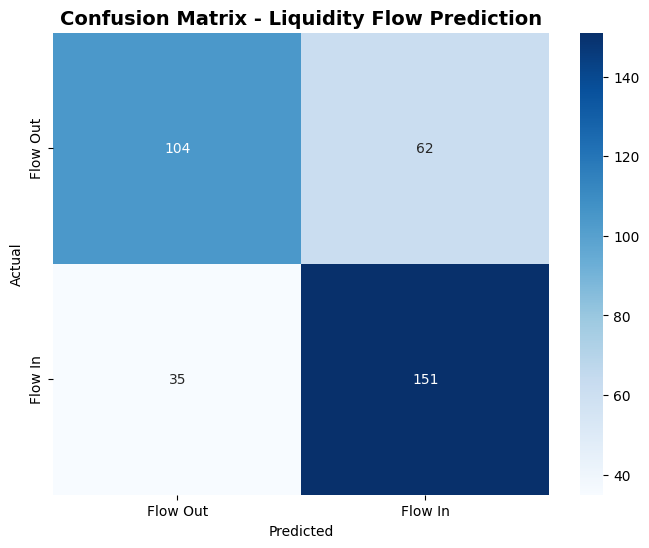

In [43]:
from matplotlib import scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

feature_cols = ['prev_tvl_change', 'tvl_momentum', 'pool_ratio', 'tvl_volatility_7d', 'day_of_week', 'pct_from_ma7']
X = df_clean[feature_cols]
y = df_clean['liquidity_flow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print(f"Testing Accuracy: {accuracy * 100:.2f}%")

report = classification_report(y_test, predictions)
print(report)

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flow Out', 'Flow In'], yticklabels=['Flow Out', 'Flow In'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Liquidity Flow Prediction', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

             Feature  Coefficient
1       tvl_momentum     1.691619
0    prev_tvl_change    -1.130468
3  tvl_volatility_7d     0.271238
2         pool_ratio    -0.149689
5       pct_from_ma7     0.087093
4        day_of_week     0.021990


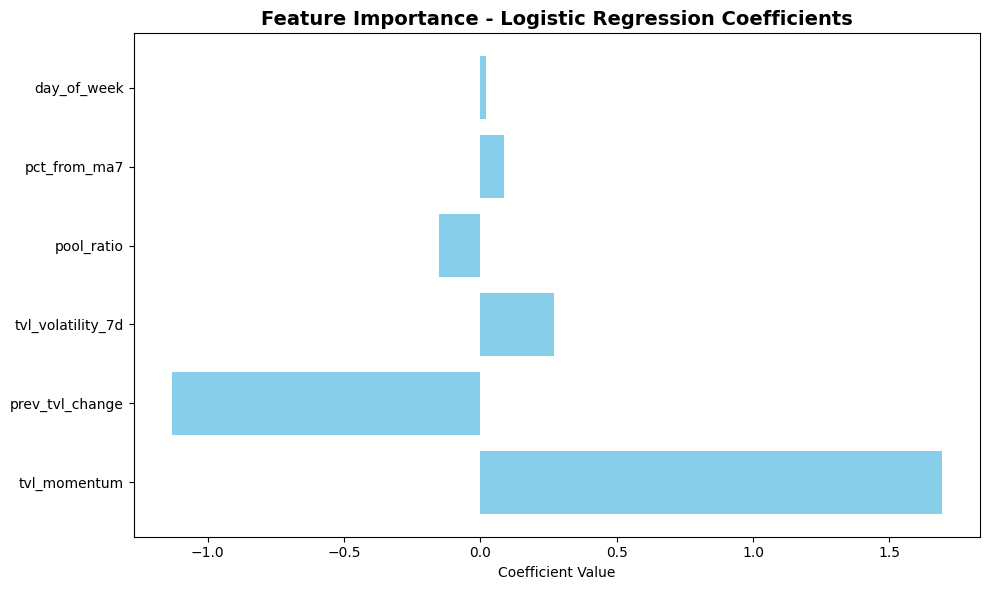

In [44]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Logistic Regression Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()